# Loss Functions for Image Inpainting

<div style="margin:.3rem 0 1rem;font-size:.9em;color:#555;display:flex;align-items:center;gap:.35rem;font-family:monospace">
  <time datetime="2026-05-02">2 May 2026</time>
</div>

<a href="https://colab.research.google.com/github/shahaliyev/csci4701/blob/main/docs/supplementary/inpainting_losses.ipynb"
   target="_blank" rel="noopener">
  <img
    src="https://colab.research.google.com/assets/colab-badge.svg"
    alt="Open in Colab"
   loading="lazy" decoding="async"/>
</a>

Image inpainting losses are the objectives used to train a model to reconstruct missing regions of an image. While metrics are used after an output has been produced, losses are used during optimization. The same mathematical idea can appear in both places, but the role is different: a metric evaluates, while a loss produces gradients.Image inpainting aims to reconstruct the missing regions of an image from the visible regions.Let

$$
x \in \mathbb{R}^{H \times W \times 3}
$$

denote the ground-truth image, and

$$
m \in \{0,1\}^{H \times W}
$$

be a binary mask. The mask has the same spatial size as the image, but it has no color channel dimension. Each value of $m$ is either $0$ or $1$. A value of $m=1$ indicates a known pixel, meaning that the original image value is visible and available to the model. A value of $m=0$ indicates a missing pixel, meaning that this part of the image has been removed and must be reconstructed. The corrupted input is

$$
x_{\mathrm{corrupt}} = x \odot m,
$$

where $x_{\mathrm{corrupt}}$ is the damaged image given to the model and $\odot$ denotes element-wise multiplication. Since $x$ has shape $H \times W \times 3$ and $m$ has shape $H \times W$, the mask is applied to every color channel at the same spatial location. Pixels where $m=1$ are kept unchanged, while pixels where $m=0$ are set to zero. Therefore, $x \odot m$ keeps the known region and removes the missing region. An inpainting model then predicts

$$
\hat{x} = f_\theta(x \odot m, m).
$$

Here, $\hat{x}$ denotes the predicted complete image. The function $f_\theta$ is the inpainting model, and $\theta$ denotes its learnable parameters. The model receives two inputs: the corrupted image $x \odot m$ and the mask $m$. The corrupted image shows the visible content, while the mask tells the model which pixels are known and which pixels must be filled. The goal is for $\hat{x}$ to be close to the original image $x$, especially inside the missing region where $m=0$.

This notebook groups inpainting losses by what they compare: direct pixel values, deep feature activations, texture statistics, discriminator judgments, local smoothness, frequency content, and diffusion noise. The goal is not to list every possible loss, but to understand what each common loss asks the model to do and what kind of behavior it encourages. The notebook will discuss the following loss families:

- pixel-wise reconstruction loss
- perceptual loss
- style loss
- total variation loss
- adversarial loss
- frequency-domain loss
- diffusion denoising objective
- model-specific composite objectives

Before introducing the losses, we use the same kind of small image example as in the metrics notebook. We load one natural RGB image from the [Oxford-IIIT Pet](https://www.robots.ox.ac.uk/~vgg/data/pets/) dataset, resize and center-crop it to $256 \times 256$, and store it in tensor format $(N,C,H,W)$. We then create a binary hole mask, a corrupted input, and a few artificial predictions. These predictions are not produced by a trained model; they are simple controlled examples for inspecting how different losses behave.


In [1]:
import matplotlib.pyplot as plt

def show(images, titles=None, figsize=None):
    if isinstance(images, dict):
        titles, images = list(images.keys()), list(images.values())
    fig, axes = plt.subplots(1, len(images), figsize=figsize or (3 * len(images), 4))
    axes = [axes] if len(images) == 1 else axes
    for ax, img, title in zip(axes, images, titles or [""] * len(images)):
        img = img[0] if img.ndim == 4 else img
        img = img[0] if img.ndim == 3 and img.shape[0] == 1 else img
        img = img.permute(1, 2, 0) if img.ndim == 3 and img.shape[0] == 3 else img
        img = img.detach().cpu().clamp(0, 1)
        ax.imshow(img, cmap="gray" if img.ndim == 2 else None)
        ax.set_title(title)
        ax.axis("off")
    plt.tight_layout()


In [2]:
from torchvision.datasets import OxfordIIITPet
from torchvision.transforms import Compose, Resize, CenterCrop, ToTensor

transform = Compose([Resize(256), CenterCrop(256), ToTensor()])
data = OxfordIIITPet(root="./data", split="test", target_types="category", download=True, transform=transform)

x, label = data[111]
x = x.unsqueeze(0)

x.shape, x.min(), x.max()


(torch.Size([1, 3, 256, 256]), tensor(0.), tensor(0.9059))

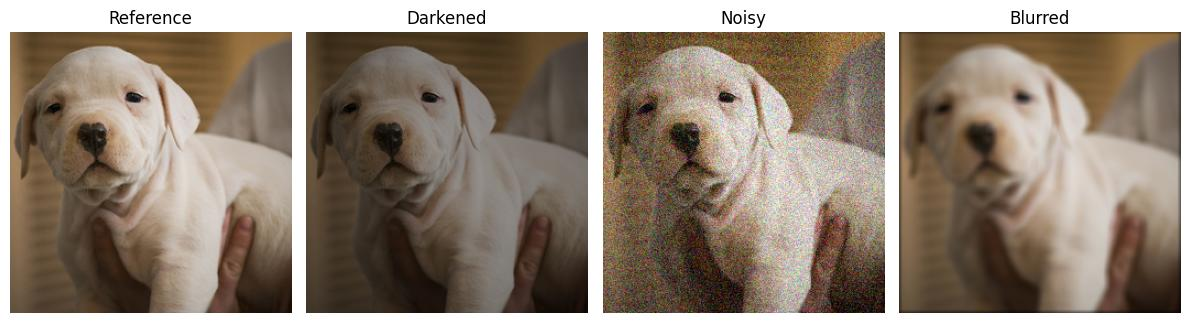

In [3]:
import torch
import torch.nn.functional as F

torch.manual_seed(0)

x_dark = (0.65 * x).clamp(0, 1)
x_noisy = (x + 0.1 * torch.randn_like(x)).clamp(0, 1)
x_blur = F.avg_pool2d(x, kernel_size=7, stride=1, padding=3)

images = {"Reference": x, "Darkened": x_dark, "Noisy": x_noisy, "Blurred": x_blur}
show(images)


Before introducing losses, we again need to define the inpainting mask. We use the convention $m=1$ for known pixels and $m=0$ for missing pixels. Therefore, $m$ selects the visible region and $1-m$ selects the hole. This distinction is essential because inpainting losses are often split into a valid-region term and a hole-region term. The hole term teaches the model to reconstruct missing content, while the valid-region term discourages the model from changing pixels that were already observed.


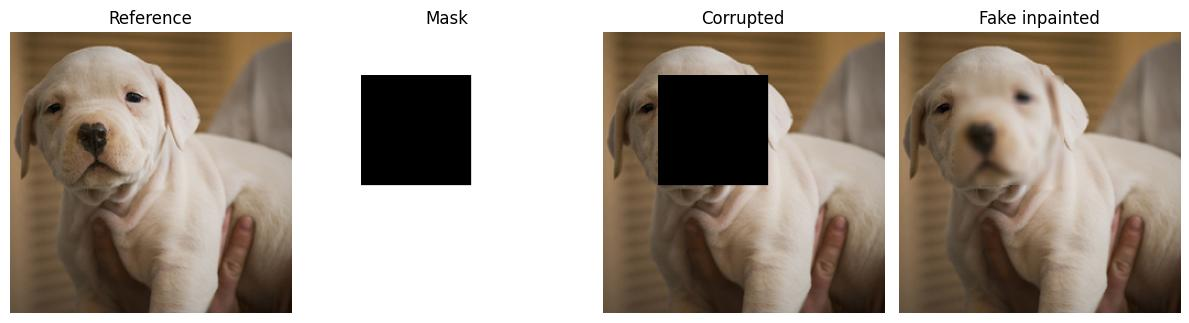

In [4]:
def get_box_mask(x, top=40, left=50, height=100, width=100):
    mask = torch.ones(x.shape[0], 1, x.shape[2], x.shape[3], device=x.device)
    mask[:, :, top:top+height, left:left+width] = 0
    return mask

mask = get_box_mask(x)

x_corrupted = x * mask
x_inpainted = x_corrupted + x_blur * (1 - mask)

show({"Reference": x, "Mask": mask, "Corrupted": x_corrupted, "Fake inpainted": x_inpainted})


In [5]:
import pandas as pd

# helpers
def get_mean(x, mask=None, eps=1e-8):
    if mask is None:
        return x.mean()
    mask = mask.expand_as(x)
    return (x * mask).sum() / mask.sum().clamp_min(eps)

def plot_table(scores, decimals=4):
    table = pd.DataFrame(scores).T
    if isinstance(table.iloc[0, 0], dict):
        table = pd.concat({row: pd.Series(cols) for row, cols in scores.items()}, axis=1).T
    table = table.map(lambda v: v.item() if torch.is_tensor(v) else v)
    return table.round(decimals)


## Pixel-Wise Reconstruction Losses

The simplest training objective compares the predicted image $\hat{x}$ directly with the ground-truth image $x$. This is usually called a _reconstruction loss_. In ordinary supervised restoration, the loss may be computed over the whole image. In inpainting, it is more useful to separate the hole and known regions:

$$
\mathcal{L}_{\mathrm{rec}}
=
\lambda_h
\left\|
(1-m) \odot (\hat{x}-x)
\right\|_1
+
\lambda_v
\left\|
m \odot (\hat{x}-x)
\right\|_1.
$$

Here, $\lambda_h$ weights the missing region and $\lambda_v$ weights the known region. The hole-region loss is usually more important because this is the part the model must synthesize. The valid-region loss is still useful because it discourages unnecessary changes to visible pixels. If the final output is formed by compositing,

$$
x_{\mathrm{comp}} = m \odot x + (1-m) \odot \hat{x},
$$

then known pixels are copied from the input and the valid-region loss may become less important. If the network directly outputs the full image, the valid-region term helps preserve visible content.

The formula above uses an $L_1$ loss. This is common in image restoration because it penalizes errors linearly: doubling the prediction error doubles the loss. An $L_2$ or MSE loss instead squares the error, so large mistakes receive much stronger penalties.

The more important difference is what these losses encourage when the answer is uncertain. If a missing region has several plausible reconstructions, a pixel-wise loss does not know which one looks most realistic. It only compares the prediction to the available target image. Under an $L_2$ loss, the safest prediction is often the average of the possible targets. This happens because the value that minimizes expected squared error is the conditional mean. If the model is unsure whether a missing patch should contain one texture, another texture, or a slightly shifted edge, the mean of these possibilities can become a smooth mixture.

Mathematically, the averaging effect comes directly from the shape of the $L_2$ formula. For several plausible target values $x_1,\dots,x_n$, squared error minimizes $\sum_i(\hat{x}-x_i)^2$; setting its derivative to zero gives $2\sum_i(\hat{x}-x_i)=0$, so $\hat{x}=\frac{1}{n}\sum_i x_i$. In other words, the best prediction under $L_2$ is the mean of the possible targets. This is harmful in inpainting because the mean of several sharp but different completions is usually not itself sharp. By contrast, $L_1$ minimizes $\sum_i|\hat{x}-x_i|$, whose slope is only $-1$ or $+1$ depending on whether $\hat{x}$ is below or above each target value. The optimum is therefore the point where the number of targets on both sides is balanced, which is the median. This is why $L_1$ is usually less averaging than $L_2$, although it is still a pixel-wise objective and can still produce conservative results when the missing region has many valid completions.

This is why $L_2$ loss often produces blurry outputs in restoration and inpainting. Sharp textures, edges, and object details usually require committing to one specific plausible solution. Averaging multiple plausible solutions removes high-frequency detail. For example, if one valid reconstruction contains a dark edge slightly to the left and another contains the same edge slightly to the right, their average may contain neither sharp edge clearly. The result can have good pixel-wise error but poor visual realism.

An $L_1$ loss does not fully solve the problem. Inpainting is inherently ambiguous: many completions may be valid for the same visible context. Therefore, pixel-wise losses alone still tend to produce conservative outputs, especially for large holes, complex textures, and semantically uncertain regions.

In [6]:
def l1_loss(x, y, mask=None):
    return get_mean((x - y).abs(), mask)

def l2_loss(x, y, mask=None):
    return get_mean((x - y) ** 2, mask)

def reconstruction_loss(x, y, mask, lambda_hole=6.0, lambda_valid=1.0):
    hole = 1 - mask
    valid = mask
    return lambda_hole * l1_loss(x, y, hole) + lambda_valid * l1_loss(x, y, valid)

In [7]:
predictions = {
    "Reference": x,
    "Corrupted": x_corrupted,
    "Fake inpainted": x_inpainted,
    "Blurred image": x_blur,
    "Darkened image": x_dark,
}

scores = {}
for name, img in predictions.items():
    scores[name] = {
        "Full L1": l1_loss(x, img),
        "Hole L1": l1_loss(x, img, 1 - mask),
        "Valid L1": l1_loss(x, img, mask),
        "Full L2": l2_loss(x, img),
        "Hole L2": l2_loss(x, img, 1 - mask),
        "Valid L2": l2_loss(x, img, mask),
        "Reconstruction": reconstruction_loss(x, img, mask),
    }

plot_table(scores)


,Full L1,Hole L1,Valid L1,Full L2,Hole L2,Valid L2,Reconstruction
Reference,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
Corrupted,0.0894,0.5861,0.0000,0.0602,0.3946,0.0000,3.5165
Fake inpainted,0.0046,0.0300,0.0000,0.0004,0.0023,0.0000,0.1800
Blurred image,0.0196,0.0300,0.0177,0.0015,0.0023,0.0014,0.1977
Darkened image,0.1609,0.2051,0.1529,0.0318,0.0483,0.0288,1.3837


The table shows how mask-aware reconstruction loss differs from full-image reconstruction loss. The corrupted image has zero valid-region error because the known pixels are copied from the reference, but it has large hole-region error because the missing region is black. The fake inpainted image has smaller hole error because the hole has been filled with a blurred version of the reference. The blurred image changes the whole image, so it has both hole and valid error. The darkened image has error everywhere because all pixel values are shifted.

The weighted reconstruction loss emphasizes the hole through $\lambda_h$. This is useful because the missing region may occupy only a small part of the image. If the loss were averaged over the whole image without mask awareness, the known pixels could dominate the objective, and the model could appear to perform well while still reconstructing the hole poorly. We discussed that the choice between $L_1$ and $L_2$ changes the gradient signal. For one scalar prediction $\hat{x}$ and target $x$, the losses are

$$
\mathcal{L}_1 = |\hat{x}-x|,
\qquad
\mathcal{L}_2 = (\hat{x}-x)^2.
$$

The $L_1$ loss gives a constant-magnitude slope away from zero error, while $L_2$ gives a slope that grows with the error size. In image restoration, $L_2$ is mathematically convenient and closely related to PSNR, but it often encourages smoother predictions. $L_1$ is usually a stronger default for deterministic image reconstruction because it is less dominated by a few large errors.


## Perceptual Loss

Pixel-wise losses compare corresponding pixels. _Perceptual loss_ compares images in the feature space of a pretrained neural network. Instead of asking whether $\hat{x}$ and $x$ have the same RGB values at every location, it asks whether their intermediate visual representations are similar. A common form is

$$
\mathcal{L}_{\mathrm{perc}}
=
\sum_l
\left\|
\phi_l(\hat{x}) - \phi_l(x)
\right\|_1,
$$

where $\phi_l(\cdot)$ denotes the activation map from layer $l$ of a pretrained network, usually VGG. This idea is widely used in image transformation tasks, where feature-space losses can produce visually better outputs than pure pixel losses ([Johnson et al., 2016](https://arxiv.org/abs/1603.08155)). For inpainting, perceptual loss encourages the filled region to match the reference at a higher visual level. It can help preserve edges, object parts, and texture layout better than pixel-wise loss alone. However, perceptual loss is still a supervised full-reference objective: it compares the prediction to one ground-truth image. It does not solve the ambiguity problem completely because there may be several plausible completions different from the recorded ground truth.

The main difference from pixel-wise loss is that the comparison happens after both images pass through a feature extractor. In a convolutional network, early layers usually respond to local visual patterns such as edges, corners, simple colors, and textures, while deeper layers respond to more abstract structures such as object parts and semantic layout. Therefore, two images can have different RGB values but still have similar feature activations. This is useful for inpainting because the generated region does not always need to match the ground-truth pixels exactly to look correct. For example, a slightly shifted texture may receive a large pixel-wise error, but a smaller perceptual error if the pretrained network extracts similar visual features from both images. In this sense, perceptual loss is less rigid than $L_1$ or $L_2$ loss, because it compares visual representation rather than raw pixels.

In [8]:
from torchvision.models import vgg16, VGG16_Weights

vgg = vgg16(weights=VGG16_Weights.DEFAULT).features[:16].eval()
for p in vgg.parameters():
    p.requires_grad_(False)

def imagenet_normalize(x):
    mean = torch.tensor([0.485, 0.456, 0.406], device=x.device).view(1, 3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225], device=x.device).view(1, 3, 1, 1)
    return (x - mean) / std

def extract_vgg_features(x, layers=[3, 8, 15]):
    feats = []
    x = imagenet_normalize(x)
    for i, layer in enumerate(vgg.to(x.device)):
        x = layer(x)
        if i in layers:
            feats.append(x)
    return feats

In [9]:
def perceptual_loss(x, y, mask=None):
    x_feats = [f.detach() for f in extract_vgg_features(x)]
    y_feats = extract_vgg_features(y)
    losses = []
    for fx, fy in zip(x_feats, y_feats):
        d = (fx - fy).abs()
        if mask is not None:
            m = F.interpolate(mask, size=d.shape[-2:], mode="nearest")
            losses.append(get_mean(d, m))
        else:
            losses.append(d.mean())
    return torch.stack(losses).mean()

scores = {}
for name, img in predictions.items():
    scores[name] = {
        "Full perceptual": perceptual_loss(x, img),
        "Hole perceptual": perceptual_loss(x, img, 1 - mask),
        "Hole L1": l1_loss(x, img, 1 - mask),
        "Hole L2": l2_loss(x, img, 1 - mask),
    }

plot_table(scores)


,Full perceptual,Hole perceptual,Hole L1,Hole L2
Reference,0.0000,0.0000,0.0000,0.0000
Corrupted,0.2269,1.0861,0.5861,0.3946
Fake inpainted,0.1215,0.7010,0.0300,0.0023
Blurred image,0.4721,0.6836,0.0300,0.0023
Darkened image,0.1563,0.2096,0.2051,0.0483


In real training, the pretrained VGG network is frozen, but gradients still flow through the prediction $\hat{x}$. The target features $\phi_l(x)$ can be detached because the ground-truth image is not being optimized. The prediction features $\phi_l(\hat{x})$ should not be detached during training, otherwise the perceptual loss would not update the inpainting model.

Even from the code it is obvious that the perceptual loss is closely related to LPIPS (Learned Perceptual Image Patch Similarity). LPIPS also compares two images using deep neural network features and was proposed as a perceptual similarity metric that correlates better with human judgments than traditional metrics such as PSNR and SSIM ([Zhang et al., 2018](https://arxiv.org/abs/1801.03924)). A simplified way to view LPIPS is that it computes feature differences between two images across several layers of a pretrained network. However, LPIPS is more carefully designed as an evaluation metric: it typically normalizes feature activations, compares them layer by layer, and uses learned linear weights calibrated using human perceptual similarity judgments. By contrast, the perceptual loss used here is simpler. We directly extract VGG feature maps from selected layers and compute an ordinary $L_1$ distance between the predicted image features and the target image features. So the idea is similar to LPIPS, but the implementation is lighter: no learned perceptual calibration, no separate LPIPS package, and no extra weighting beyond the selected feature layers.

Perceptual loss should therefore be understood as a training loss, not just an evaluation metric. During training, gradients flow through the pretrained feature extractor back to the inpainting model, but the pretrained network itself is kept fixed. The model is not trained to simply copy pixels; it is trained to produce outputs whose internal feature representations resemble those of the ground-truth image. This helps reduce the overly smooth appearance often caused by pixel-wise losses alone. Still, perceptual loss has limits. Because it is computed against one reference image, it can penalize plausible completions that differ from the dataset target. It also depends on the pretrained network and selected layers, so it may emphasize features that are useful for natural-image recognition but not always ideal for every restoration domain.


## Style Loss

_Style loss_ also uses pretrained feature maps, but it compares **texture statistics** rather than direct feature activations. The usual form comes from neural style transfer, where style is represented by correlations between feature channels instead of exact spatial content ([Gatys et al., 2015](https://arxiv.org/abs/1508.06576); [Gatys et al., 2016](https://openaccess.thecvf.com/content_cvpr_2016/html/Gatys_Image_Style_Transfer_CVPR_2016_paper.html)). For a feature map $F \in \mathbb{R}^{C \times H \times W}$, $C$ is the number of feature channels, and $H \times W$ is the spatial resolution of the feature map. We first flatten the spatial dimensions so that

$$
F \in \mathbb{R}^{C \times HW}.
$$

Each row of this flattened matrix corresponds to one feature channel, and each column corresponds to one spatial location. The [Gram matrix](https://en.wikipedia.org/wiki/Gram_matrix) is then

$$
G(F) = \frac{F F^\top}{CHW}.
$$

Here, $F F^\top$ produces a matrix of shape $C \times C$. Each entry of this matrix measures how strongly two feature channels activate together across the image. If two channels often respond at the same locations, their Gram-matrix value becomes large. If they rarely respond together, the value is smaller. The division by $CHW$ is a normalization term that keeps the scale of the Gram matrix more stable when the number of channels or spatial locations changes.

Intuitively, each feature channel can be understood as a detector for some visual pattern, such as an edge direction, color contrast, repeated texture, or more complex local structure. After flattening $F$ into shape $C \times HW$, each channel becomes a long vector showing how strongly that pattern appears at every spatial location. When we compute $F F^\top$, we compare every channel with every other channel using dot products. If two patterns tend to appear together across the image, their vectors point in a similar direction and their dot product becomes large. If they do not appear together, the dot product is smaller. Therefore, the Gram matrix does not describe exactly where a pattern appears; it describes which patterns tend to appear together. This is why it is useful for style or texture: textures are often defined less by exact position and more by repeated co-occurrence of visual patterns. The division by $CHW$ simply prevents the Gram values from becoming larger just because the feature map has more channels or more spatial locations, making the statistic easier to compare across layers. The style loss is then

$$
\mathcal{L}_{\mathrm{style}}
=
\sum_l
\left\|
G(\phi_l(\hat{x})) - G(\phi_l(x))
\right\|_1.
$$

Here, $\phi_l(\hat{x})$ and $\phi_l(x)$ are feature maps extracted from layer $l$ of a fixed pretrained network, usually VGG. The Gram matrices summarize the feature-channel correlations of the predicted image and the ground-truth image. The loss then penalizes the difference between these two Gram matrices. Therefore, the model is not asked to place every feature at exactly the same spatial position. Instead, it is asked to make the predicted image have similar feature co-occurrence statistics to the reference image. This is the key difference between perceptual loss and style loss. Perceptual loss compares feature activations directly:

$$
\phi_l(\hat{x}) \approx \phi_l(x).
$$

Style loss compares feature correlations:

$$
G(\phi_l(\hat{x})) \approx G(\phi_l(x)).
$$

Because the Gram matrix aggregates information over spatial locations, it largely discards exact position. For inpainting, this is useful when the missing region should contain a similar texture but does not need to reproduce the exact same pixel arrangement. For example, grass, hair, fabric, clouds, walls, and repeated patterns can look realistic even when their exact local arrangement differs from the ground truth. Style loss encourages this kind of texture realism because it matches how visual features appear together, not where every feature appears.

However, this is also the limitation of style loss. Since the Gram matrix does not preserve precise spatial layout, it cannot guarantee semantic correctness. A generated region may have plausible texture statistics but still place structures incorrectly. For example, style loss may help a wall texture look natural, but it cannot by itself ensure that a window, eye, road boundary, or object contour is placed in the correct location. Therefore, style loss is usually used together with reconstruction and perceptual losses rather than alone.

In [10]:
def gram_matrix(f):
    n, c, h, w = f.shape
    f = f.view(n, c, h * w)
    return torch.bmm(f, f.transpose(1, 2)) / (c * h * w)

def style_loss(x, y):
    x_feats = [f.detach() for f in extract_vgg_features(x)]
    y_feats = extract_vgg_features(y)
    losses = []
    for fx, fy in zip(x_feats, y_feats):
        losses.append((gram_matrix(fx) - gram_matrix(fy)).abs().mean())
    return torch.stack(losses).mean()

comparison = {
    "Original": x,
    "Blurred": x_blur,
    "Different image": data[0][0].unsqueeze(0),
}

scores = {}
for name, img in comparison.items():
    scores[name] = {"Style loss": style_loss(x, img)}

plot_table(scores)


,Style loss
Original,0.0000
Blurred,0.0014
Different image,0.0039


In our implementation, style loss is simpler than the full neural style transfer setting. We are not transferring the artistic style of one image onto the content of another image. We use the same idea only as a regularizer for inpainting: extract VGG feature maps from $\hat{x}$ and $x$, compute Gram matrices at selected layers, and apply an $L_1$ distance between them. This gives the model an additional signal for texture consistency without introducing a separate style image, a style-transfer optimization loop, or learned perceptual weights. The goal is not stylization, but more realistic local texture inside the reconstructed region.


## Total Variation Loss

_Total variation (TV)_ loss is a smoothness regularizer. Unlike reconstruction, perceptual, and style losses, it does not directly compare the prediction to a ground-truth image. Instead, it looks only at the local changes inside the predicted image and penalizes neighboring pixels that differ too strongly. In its common anisotropic form, it is written as

$$
\mathcal{L}_{\mathrm{TV}}
=
\sum_{i,j}
\left(
|\hat{x}_{i,j} - \hat{x}_{i+1,j}|
+
|\hat{x}_{i,j} - \hat{x}_{i,j+1}|
\right).
$$

Here, $\hat{x}_{i,j}$ denotes the predicted pixel at spatial location $(i,j)$. The first term compares a pixel with the pixel below it, and the second term compares it with the pixel to its right. If neighboring pixels are very different, the TV value becomes large. If neighboring pixels change gradually, the TV value becomes small. Therefore, TV loss encourages local spatial smoothness by penalizing large horizontal and vertical differences. This idea comes from total variation regularization in image denoising, where images with excessive noisy fluctuations are treated as having high total variation ([Rudin et al., 1992](https://www.sciencedirect.com/science/article/pii/016727899290242F); [Getreuer, 2012](https://www.ipol.im/pub/art/2012/g-tvd/)).

In [11]:
def tv_loss(y, mask=None):
    dh = (y[:, :, 1:, :] - y[:, :, :-1, :]).abs()
    dw = (y[:, :, :, 1:] - y[:, :, :, :-1]).abs()
    if mask is None:
        return dh.mean() + dw.mean()
    mh = mask[:, :, 1:, :] * mask[:, :, :-1, :]
    mw = mask[:, :, :, 1:] * mask[:, :, :, :-1]
    return get_mean(dh, mh) + get_mean(dw, mw)

scores = {}
for name, img in predictions.items():
    scores[name] = {"Full TV": tv_loss(img), "Hole TV": tv_loss(img, 1 - mask)}

plot_table(scores)


,Full TV,Hole TV
Reference,0.0263,0.0520
Corrupted,0.0217,0.0000
Fake inpainted,0.0220,0.0235
Blurred image,0.0165,0.0235
Darkened image,0.0171,0.0338


In inpainting, TV loss is usually added with a small weight. Its purpose is not to reconstruct the missing content by itself, but to suppress unwanted local artifacts such as isolated spikes, noisy pixels, and checkerboard-like patterns. A noisy image usually has a high TV value because neighboring pixels fluctuate strongly. A blurred image usually has a low TV value because local changes have been smoothed out. This shows both the strength and the danger of TV loss. It can reduce unnatural high-frequency noise, but if its weight is too large, it also suppresses real high-frequency detail such as hair, grass, fabric, cloud boundaries, edges, and fine texture. Therefore, TV loss should be treated as a stabilizer, not as the main objective. In a practical inpainting objective, it is normally combined with reconstruction, perceptual, or style losses so that the output remains faithful and visually meaningful while avoiding unnecessary local artifacts.


## Adversarial Loss

Reconstruction, perceptual, style, and TV losses are all manually defined ways of judging an image. We decide in advance what should be penalized: wrong pixels, different VGG features, different texture statistics, or excessive local variation. *Adversarial loss* works differently. Instead of writing a fixed formula for image quality, we train another small neural network to judge realism. This second network is called the **discriminator**. It is not given by the dataset and it is not a pretrained VGG-like network. We define it ourselves, usually as a CNN, and train it together with the inpainting model. In GAN terminology, the inpainting model is the **generator** $G$, because it generates the completed image, and the discriminator $D$ is an extra model trained only to tell whether an image or patch looks real or generated ([Goodfellow et al., 2014](https://arxiv.org/abs/1406.2661)).

The basic idea is simple. During training, the discriminator sees two kinds of examples. First, it sees real complete images from the dataset, which should be classified as real. Second, it sees completed images produced by the generator, which should be classified as fake. Therefore, the discriminator is trained like a binary classifier: real images should get a high score, and generated images should get a low score. The generator is trained in the opposite direction. It wants its completed image $\hat{x}$ to receive a high score from the discriminator. So the discriminator learns to detect unrealistic details, and the generator learns to avoid producing those details. For inpainting, the generator is simply the inpainting model:

$$
\hat{x} = G(x \odot m, m).
$$

Here, $G$ receives the corrupted image $x \odot m$ and the mask $m$, then outputs the completed image $\hat{x}$. The discriminator receives either the full completed image, the missing region, or local patches from the completed image. A patch-based discriminator is common because inpainting errors are often local. The whole image may look acceptable, but the filled region may contain weak edges, blurry texture, repeated artifacts, or unnatural transitions near the mask boundary. _PatchGAN-style_ discriminators judge local patches instead of giving only one score for the full image, which makes them useful for enforcing local realism ([Isola et al., 2017](https://arxiv.org/abs/1611.07004)). _Gated Convolution_ inpainting uses a spectral-normalized patch discriminator because **free-form masks** can appear anywhere, so judging many dense patches is more flexible than judging one fixed rectangular region ([Yu et al., 2019](https://arxiv.org/abs/1806.03589)).

A useful intuition is to think of the discriminator as a learned loss function. With $L_1$ or $L_2$, the loss is fixed before training begins. It cannot learn that blurry grass, strange skin texture, or broken edges look unnatural. It only knows numerical difference from the target. A discriminator, however, changes during training. If generated completions are blurry, the discriminator can learn that blur is a sign of fake images. If the generator creates checkerboard artifacts, the discriminator can learn that these artifacts are fake. Then the generator receives gradients that push it toward outputs that look more like real images. This is why adversarial loss can reduce blur and improve high-frequency detail.

The training procedure alternates between two updates. In the discriminator update, $G$ is kept fixed, and $D$ learns to separate real images from generated images. In the generator update, $D$ is kept fixed, and $G$ learns to make completions that $D$ classifies as real. So yes, adversarial training means training an extra model. We train both $G$ and $D$, but only $G$ is needed at inference time. After training finishes, the discriminator is usually discarded. At test time, the user gives a corrupted image and mask to $G$, and $G$ directly produces the inpainted result. The discriminator is only a training tool. The original GAN objective is

$$
\min_G \max_D
\mathbb{E}_{x \sim p_{\mathrm{data}}}
[\log D(x)]
+
\mathbb{E}_{z \sim p_z}
[\log(1-D(G(z)))].
$$

This formula can look more complicated than the idea behind it. The term $\mathbb{E}_{x \sim p_{\mathrm{data}}}[\log D(x)]$ trains the discriminator to give high scores to real images. The term $\mathbb{E}_{z \sim p_z}[\log(1-D(G(z)))]$ trains the discriminator to give low scores to generated images. The generator wants the opposite: it wants $D(G(z))$ to be high. In inpainting, we usually replace the unconditional generation $G(z)$ with conditional generation $G(x \odot m, m)$, because the model is not inventing an entire image from noise; it is completing a damaged image.

The important point is that adversarial loss is not a reconstruction loss. It says, "make this completed image look like it could have come from the real dataset." That is why adversarial loss can be useful when many completions are plausible. A generated region may differ from the exact ground truth but still look realistic. Pixel-wise loss may punish it, while adversarial loss may accept it. This is also the danger: a generated region can look realistic but be semantically wrong or inconsistent with the surrounding context. For this reason, adversarial loss is usually combined with reconstruction, perceptual, style, or mask-aware losses. It is best understood as a realism term: it helps the result look less blurry and more natural, but it should be balanced with losses that preserve the actual content.

In [12]:
def bce_logits_loss(logits, target):
    target = torch.full_like(logits, float(target))
    return F.binary_cross_entropy_with_logits(logits, target)

cases = {
    "D separates well": {
        "real": torch.tensor([2.5, 2.0]),
        "fake": torch.tensor([-2.0, -1.5]),
    },
    "D is uncertain": {
        "real": torch.tensor([0.2, -0.1]),
        "fake": torch.tensor([0.1, -0.2]),
    },
    "G fools D": {
        "real": torch.tensor([2.5, 2.0]),
        "fake": torch.tensor([1.5, 2.0]),
    },
}

scores = {}
for name, logits in cases.items():
    real_logits = logits["real"]
    fake_logits = logits["fake"]

    scores[name] = {
        "D real loss": bce_logits_loss(real_logits, 1),
        "D fake loss": bce_logits_loss(fake_logits, 0),
        "G adv loss": bce_logits_loss(fake_logits, 1),
    }

plot_table(scores)

,D real loss,D fake loss,G adv loss
D separates well,0.1029,0.1642,1.9142
D is uncertain,0.6713,0.6713,0.7213
G fools D,0.1029,1.9142,0.1642


In this toy example, positive logits mean that the discriminator thinks an image is real, and negative logits mean that it thinks an image is fake. The discriminator loss has two parts: real images should be classified as real, and generated images should be classified as fake. Therefore, `D real loss` is small when real logits are positive, and `D fake loss` is small when fake logits are negative. The generator adversarial loss uses the same fake logits but with the opposite target: it wants fake images to be classified as real. Therefore, `G adv loss` is large when fake logits are negative and small when fake logits are positive. This shows the adversarial conflict clearly: the discriminator is rewarded for detecting fake images, while the generator is rewarded for making fake images receive real-like discriminator scores.

## Frequency-Domain Loss

_Frequency-domain losses_ compare images after transforming them from the spatial domain into the frequency domain. In the spatial domain, an image is represented directly by pixel values. In the frequency domain, the same image is represented as a combination of spatial patterns that vary slowly or quickly across the image. The [Fourier transform](https://en.wikipedia.org/wiki/Fourier_transform) is a standard way to decompose an image into sinusoidal components of different spatial frequencies. Low spatial frequencies describe broad structure, smooth color changes, and large-scale illumination. High spatial frequencies describe rapid changes such as edges, fine texture, repeated patterns, and noise (see [MIT Vision Book](https://visionbook.mit.edu/image_processing_fourier.html); [MathWorks](https://www.mathworks.com/help/images/fourier-transform.html)). A simple frequency-domain loss compares Fourier magnitudes:

$$
\mathcal{L}_{\mathrm{freq}}
=
\left\|
|\mathcal{F}(\hat{x})| -
|\mathcal{F}(x)|
\right\|_1,
$$

where $\mathcal{F}$ denotes the two-dimensional Fourier transform, $|\mathcal{F}(\hat{x})|$ is the magnitude spectrum of the predicted image, and $|\mathcal{F}(x)|$ is the magnitude spectrum of the ground-truth image. The magnitude tells us how much of each frequency is present in the image. If two images have similar Fourier magnitudes, they contain similar amounts of low-frequency structure and high-frequency detail, even if their exact pixel values are not identical.

The intuition is that pixel-wise loss asks whether two images match at each location, while frequency loss asks whether they contain similar patterns of variation. For example, a blurred image usually loses high-frequency energy because blur removes sharp edges and fine details. A noisy image may have excessive high-frequency energy because neighboring pixels fluctuate rapidly. An image with repeated structures, such as windows, bricks, grass, fabric, waves, clouds, or satellite textures, often has characteristic frequency patterns. A frequency-domain loss can therefore encourage the prediction to match the reference not only in local pixel values, but also in global structure, repeated patterns, and sharpness.

However, this simple magnitude loss has an important limitation. The Fourier transform contains both magnitude and phase. The magnitude describes how much of each frequency exists, while the phase is strongly related to where structures appear in the image. If we compare only magnitudes, we may preserve broad frequency statistics while ignoring some spatial alignment. Therefore, a pure frequency-magnitude loss should not be used as the only objective for inpainting. It can support reconstruction, but it cannot replace losses that preserve content, location, and semantic consistency.

In [13]:
def fft_magnitude(x):
    return torch.fft.rfft2(x, norm="ortho").abs()

def frequency_loss(x, y):
    fx = torch.log1p(fft_magnitude(x))
    fy = torch.log1p(fft_magnitude(y))
    return (fx - fy).abs().mean()

scores = {}
for name, img in predictions.items():
    scores[name] = {"Frequency loss": frequency_loss(x, img)}

plot_table(scores)


,Frequency loss
Reference,0.0000
Corrupted,0.0139
Fake inpainted,0.0071
Blurred image,0.0160
Darkened image,0.0084


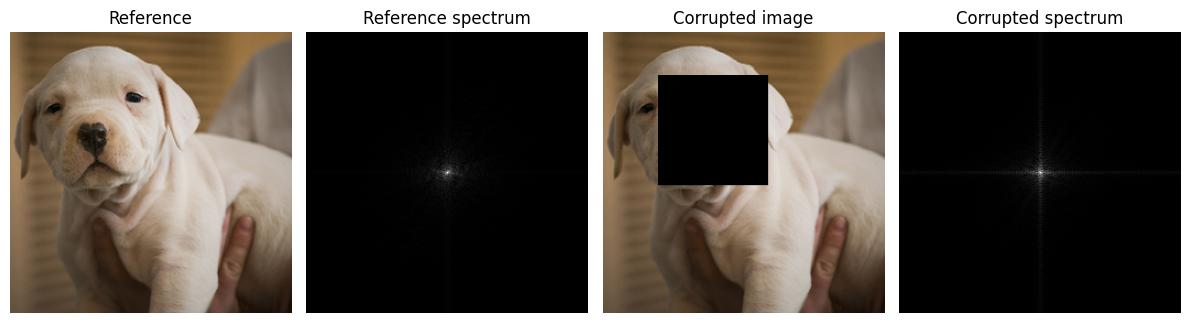

In [14]:
def spectrum_image(x):
    z = torch.fft.fftshift(torch.fft.fft2(x, norm="ortho"), dim=(-2, -1)).abs().log1p()
    z = z.mean(dim=1, keepdim=True)
    z = (z - z.amin(dim=(-2, -1), keepdim=True)) / (z.amax(dim=(-2, -1), keepdim=True) - z.amin(dim=(-2, -1), keepdim=True) + 1e-8)
    return z.repeat(1, 3, 1, 1)

show({
    "Reference": x,
    "Reference spectrum": spectrum_image(x),
    "Corrupted image": x_corrupted,
    "Corrupted spectrum": spectrum_image(x_corrupted),
})


This is related to Fourier-based inpainting models, but it should not be confused with the exact LaMa objective. LaMa ([Suvorov et al., 2021](https://arxiv.org/abs/2109.07161)) is Fourier-based mainly because its network uses **Fast Fourier Convolutions (FFCs)** ([Chi et al., 2020](https://proceedings.neurips.cc/paper_files/paper/2020/hash/2fd5d41ec6cfab47e32164d5624269b1-Abstract.html)), which provide an image-wide receptive field. The paper also emphasizes a high-receptive-field perceptual loss and large training masks, not merely a simple FFT magnitude loss. In other words, LaMa uses Fourier operations inside the model architecture to help information travel across the whole image, especially for large missing regions and periodic structures. The simple frequency loss above is pedagogical: it shows one direct way to compare images outside pixel space, but it is much simpler than the full LaMa design.

## Composite Inpainting Loss

Classical deep inpainting methods often use several loss terms together because no single loss captures all aspects of a good reconstruction. A typical composite objective is

$$
\mathcal{L}
=
\lambda_{\mathrm{rec}}\mathcal{L}_{\mathrm{rec}}
+
\lambda_{\mathrm{perc}}\mathcal{L}_{\mathrm{perc}}
+
\lambda_{\mathrm{style}}\mathcal{L}_{\mathrm{style}}
+
\lambda_{\mathrm{tv}}\mathcal{L}_{\mathrm{TV}}
+
\lambda_{\mathrm{adv}}\mathcal{L}_{\mathrm{adv}}.
$$

Here, each $\lambda$ is a scalar weight that controls how strongly the corresponding loss contributes to the final training objective. The reconstruction loss gives direct supervised fidelity to the target image. The perceptual loss encourages similarity in pretrained feature space. The style loss encourages similar texture statistics through feature correlations. The TV loss discourages small local artifacts and excessive pixel-level noise. The adversarial loss encourages the generated output to look realistic according to a learned discriminator. This kind of composite design is common in earlier CNN-based inpainting methods. _Partial Convolution_, for example, uses pixel reconstruction, perceptual, style, and total variation losses; _Gated Convolution_ combines reconstruction with adversarial losses.

The intuition is that each term corrects a weakness of another term. Reconstruction loss keeps the output tied to the ground truth, but by itself it can produce blurry averages. Perceptual loss is less sensitive to exact pixel alignment and encourages more meaningful visual structure, but it still compares against one reference image. Style loss helps textures look statistically similar, but it does not guarantee correct spatial layout. TV loss suppresses local noise, but too much of it removes real detail. Adversarial loss encourages sharp and realistic details, but it can hallucinate plausible content that does not match the actual target. A composite loss tries to balance these pressures: one term keeps the output faithful, another makes it perceptually reasonable, another improves texture, another stabilizes local smoothness, and another pushes realism.

The difficulty is not writing the formula. The difficulty is **choosing the weights**. If $\lambda_{\mathrm{rec}}$ is too large, the model may become conservative: it stays close to the ground truth in pixel space but produces smooth, weak, or blurry completions. If $\lambda_{\mathrm{adv}}$ is too large, the result may look sharper but become less faithful to the image context. If $\lambda_{\mathrm{style}}$ is too large, the texture statistics may look plausible while object structure becomes less accurate. If $\lambda_{\mathrm{tv}}$ is too large, the model is rewarded for smoothness and may erase fine details such as hair, grass, fabric, clouds, or edges. Therefore, the final loss is best understood as a trade-off rather than a single universal objective.

In practice, the weights are usually chosen empirically. A reasonable strategy is to start with reconstruction loss as the anchor, then add perceptual or style loss to improve visual quality, and only add adversarial or TV terms if there is a clear reason. For example, adversarial loss is useful when outputs are too blurry but can make training unstable. TV loss is useful when outputs contain small artifacts but should be kept weak. The correct weighting depends on the dataset, mask size, architecture, and evaluation goal. For small missing regions, reconstruction may be enough. For large holes and complex textures, perceptual, style, adversarial, or frequency-aware terms may become more important.

This is also why modern inpainting methods differ in how much they rely on composite losses. Earlier CNN-based systems often compensated for limited modeling capacity by combining many explicit losses. Later methods increasingly move some of the burden into the architecture or training formulation itself. LaMa, for example, emphasizes large receptive fields through FFC and a high-receptive-field perceptual loss, which helps global structure and periodic patterns. Diffusion-based inpainting goes even further: it often replaces hand-designed reconstruction-style objectives with a denoising objective that learns a data distribution. In that sense, composite losses are useful for understanding classical supervised inpainting, but they are also a sign of the central difficulty: image quality is not one property, so different loss terms are used to approximate different parts of it.

In [15]:
def composite_loss(x, y, mask, weights):
    terms = {
        "rec": reconstruction_loss(x, y, mask),
        "perc": perceptual_loss(x, y, 1 - mask),
        "style": style_loss(x, y),
        "tv": tv_loss(y, 1 - mask),
        "freq": frequency_loss(x, y),
    }
    total = sum(weights[k] * terms[k] for k in weights)
    terms["total"] = total
    return terms

weights = {"rec": 1.0, "perc": 0.1, "style": 10.0, "tv": 0.01, "freq": 0.1}

scores = {}
for name, img in predictions.items():
    scores[name] = composite_loss(x, img, mask, weights)

plot_table(scores)


,rec,perc,style,tv,freq,total
Reference,0.0000,0.0000,0.0000,0.0520,0.0000,0.0005
Corrupted,3.5165,1.0861,0.0010,0.0000,0.0139,3.6361
Fake inpainted,0.1800,0.7010,0.0005,0.0235,0.0071,0.2560
Blurred image,0.1977,0.6836,0.0014,0.0235,0.0160,0.2819
Darkened image,1.3837,0.2096,0.0008,0.0338,0.0084,1.4133


The absolute values of the terms are not directly comparable. Style loss may be numerically much smaller than reconstruction loss, while TV may have another scale. This is why the weights matter. A coefficient such as $\lambda_{\mathrm{style}}=10$ does not automatically mean style is ten times more important; it compensates for the numerical scale of that term. In real experiments, loss weights should be reported clearly because they are part of the method.

## Diffusion-Based Inpainting Objective

Diffusion-based inpainting is different from the previous losses because it does not usually train the model by directly comparing the final completed image $\hat{x}$ with the ground-truth image $x$ using reconstruction, perceptual, style, TV, or adversarial terms. In a basic DDPM-style formulation, the model is trained as a denoiser. A clean image $x_0$ is gradually corrupted by Gaussian noise to obtain a noisy image $x_t$:

$$
x_t
=
\sqrt{\bar{\alpha}_t}x_0
+
\sqrt{1-\bar{\alpha}_t}\epsilon,
\qquad
\epsilon \sim \mathcal{N}(0,I).
$$

Here, $t$ is the diffusion timestep, $\epsilon$ is the Gaussian noise added to the image, and $\bar{\alpha}_t$ controls how much of the original image remains at timestep $t$. For small $t$, $x_t$ is still close to the original image. For large $t$, $x_t$ becomes mostly noise. The neural network is trained to predict the noise that was added:

$$
\mathcal{L}_{\mathrm{diff}}
=
\mathbb{E}_{t,\epsilon}
\left[
\left\|
\epsilon
-
\epsilon_\theta(x_t,t)
\right\|_2^2
\right].
$$

Here, $\epsilon_\theta(x_t,t)$ is the model’s predicted noise. The loss is small when the model correctly identifies the noise component inside $x_t$. Once the model learns this denoising task across many timesteps, it can generate images by starting from noise and repeatedly removing predicted noise step by step. This is why the objective is not a direct image reconstruction loss. It trains the model to learn the structure of the image distribution through denoising. The authors use this simplified noise-prediction objective in DDPM, where the model learns the reverse denoising process from noisy samples back toward clean images ([Ho et al., 2020](https://proceedings.neurips.cc/paper/2020/file/4c5bcfec8584af0d967f1ab10179ca4b-Paper.pdf)). For inpainting, the model must also respect the known pixels. One common conditional formulation is

$$
\mathcal{L}_{\mathrm{diff-inpaint}}
=
\mathbb{E}_{t,\epsilon}
\left[
\left\|
\epsilon
-
\epsilon_\theta(x_t,t,x \odot m,m)
\right\|_2^2
\right],
$$

where the denoising model receives the noisy image $x_t$, the timestep $t$, the corrupted known image $x \odot m$, and the mask $m$. The condition tells the model which pixels are known and what visible content should guide the missing-region generation. Instead of learning a single deterministic mapping from corrupted image to completed image, the model learns how to denoise while being guided by the visible context.

Another important approach is sampling-time conditioning. RePaint ([Lugmayr et al., 2022](https://arxiv.org/abs/2201.09865)), for example, uses a pretrained unconditional DDPM as a generative prior and modifies the reverse diffusion process so that known regions are repeatedly taken from the input image while unknown regions are generated by the diffusion model. In other words, the model does not need to be trained from scratch with a special inpainting loss. The known region is enforced during sampling, and the diffusion model fills the unknown region in a way that remains compatible with its learned image prior.

This is the main reason diffusion-based inpainting should be separated from classical composite losses. Reconstruction, perceptual, style, TV, and adversarial losses usually evaluate the final prediction $\hat{x}$ directly. Diffusion loss evaluates whether the model can predict noise at many corruption levels. The final image quality comes from the learned denoising process, not from directly optimizing PSNR, SSIM, LPIPS, or a hand-designed texture loss. This makes diffusion especially suitable for ambiguous missing regions, because the model is not forced to produce only one averaged completion. It can sample plausible completions from a learned image distribution. The trade-off is that diffusion inpainting is usually more computationally expensive at inference time because image generation requires many denoising steps rather than one forward pass.


## Model-Specific Loss Formulations and Discussion

Loss functions in image inpainting can be grouped into three broad levels. **Pixel-level losses**, such as $L_1$ and $L_2$, enforce direct numerical fidelity to the target image. **Feature-level losses**, such as perceptual and style losses, compare pretrained-network representations and texture statistics. **Distribution-level losses**, such as adversarial and diffusion objectives, try to make outputs belong to the space of realistic images rather than merely matching one target image.

These levels are not interchangeable. A pixel loss can tell the model where its prediction differs from the recorded ground truth, but it cannot judge whether a generated texture looks natural. A perceptual loss can encourage feature-level similarity, but it is still tied to one reference image and one pretrained feature extractor. A style loss can improve texture statistics, but it can ignore exact spatial arrangement. An adversarial loss can improve realism, but it may weaken paired fidelity if not balanced. A diffusion objective learns or uses a denoising distribution, but it does not directly optimize PSNR, SSIM, or LPIPS.

| Method family | Loss emphasis | Main idea |
|---|---|---|
| Partial convolution | reconstruction + perceptual + style + TV | mask-aware supervised reconstruction |
| Gated convolution | reconstruction + adversarial | learnable mask-aware features and local realism |
| LaMa / Fourier-based | perceptual-style losses + high receptive field | large-mask structure and repeated patterns |
| Transformer-based | reconstruction + perceptual/adversarial | long-range semantic structure |
| Masked autoencoding | masked reconstruction | reconstruct hidden patches or pixels |
| Diffusion inpainting | denoising / noise prediction | conditional generation from a learned image prior |

The broader pattern is that loss design evolves together with model capacity. Earlier CNN-based methods often need many explicit loss terms because the architecture has limited ability to model global structure and realistic texture by itself. Reconstruction keeps the output faithful, perceptual and style losses improve visual structure and texture, TV suppresses artifacts, and adversarial loss adds realism. LaMa and transformer methods reduce some of this burden by improving receptive field and long-range modeling. Diffusion methods shift the formulation even more strongly: instead of directly asking for one deterministic completion, they learn or use a denoising distribution that can represent multiple plausible completions.

This does not mean that newer methods make losses irrelevant. It means the role of the loss changes. In classical supervised inpainting, the loss explicitly describes what a good completion should be. In adversarial methods, part of the loss is learned through a discriminator. In Fourier-based and transformer-based methods, the architecture helps recover global context more effectively. In diffusion methods, the denoising objective trains or uses a generative prior, and inpainting becomes a conditional generation problem. Therefore, inpainting losses should not be understood as a fixed checklist. They reflect the assumptions of the model family: pixel fidelity for supervised reconstruction, feature similarity for perceptual quality, texture statistics for style, learned realism for GANs, receptive-field-aware objectives for LaMa-like systems, and probabilistic denoising for diffusion.

## Conclusion

Image inpainting losses should be understood as different ways of defining what a "good" completion means. Pixel-wise losses such as $L_1$ and $L_2$ measure direct numerical agreement with the ground truth, but they can reward overly safe or blurry predictions when several completions are plausible. Perceptual losses compare pretrained feature representations and therefore capture higher-level visual similarity. Style losses compare texture statistics through feature correlations. TV loss regularizes local smoothness and helps suppress small artifacts. Adversarial loss introduces a learned realism signal through a discriminator, while diffusion objectives shift the problem toward denoising and conditional generation rather than direct final-image comparison.

The main point is that these losses are not simple replacements for one another. Each one emphasizes a different property: fidelity, structure, texture, smoothness, realism, or distributional plausibility. Classical CNN-based inpainting methods often combine several of them because a single objective is too limited. Later approaches, such as gated, Fourier-based, transformer-based, and diffusion-based methods, move part of the burden from hand-designed losses into the architecture or generative formulation. Therefore, when reading or implementing an inpainting method, the loss function should not be viewed in isolation. It should be interpreted together with the model architecture, mask setting, dataset, and evaluation goal.